Earth Engine initialized successfully!
LULC Analysis for Irrigation Detection
Region: Haryana, India
Purpose: Agricultural land cover analysis for irrigation monitoring
Time: Summer growing season 2022
Starting LULC Analysis for Irrigation Detection
ROI: [75.0, 30.0, 76.0, 31.0]
Time period: ['2022-06-01', '2022-08-31']
Output directory: lulc_irrigation_analysis
--------------------------------------------------
1. Loading Dynamic World LULC...
Loading Dynamic World LULC for period: 2022-06-01 to 2022-08-31
Creating interactive Dynamic World map...
Creating interactive LULC map for dynamic_world
✗ Dynamic World analysis failed: 'WindowsPath' object has no attribute 'endswith'

2. Loading ESA WorldCover LULC...
Loading ESA WorldCover LULC for year: 2020
Creating ESA WorldCover plot...
Creating static LULC plot for esa_worldcover
✗ Dynamic World analysis failed: 'WindowsPath' object has no attribute 'endswith'

2. Loading ESA WorldCover LULC...
Loading ESA WorldCover LULC for year: 2020


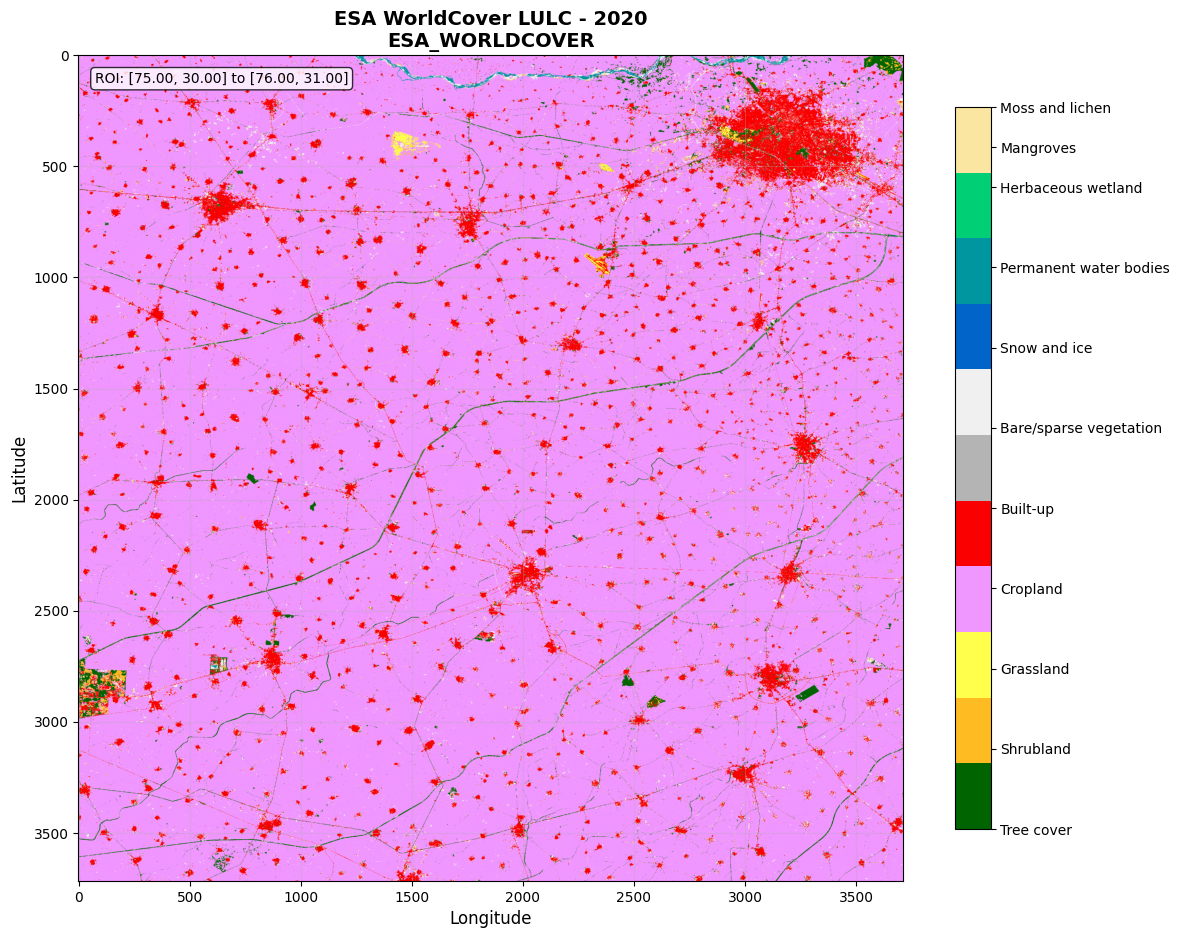

Analyzing ESA WorldCover composition...
Analyzing LULC composition for esa_worldcover
✗ ESA WorldCover analysis failed: Group input must come after weighted inputs.

3. Creating LULC product comparison...
Comparing different LULC products...
Loading Dynamic World LULC for period: 2022-06-01 to 2022-08-31
✓ Dynamic World loaded
Loading ESA WorldCover LULC for year: 2022
✓ ESA WorldCover loaded
Loading MODIS Land Cover for year: 2022
✓ MODIS Land Cover loaded
Comparison plot saved to: lulc_irrigation_analysis\lulc_comparison_2022.png
✗ ESA WorldCover analysis failed: Group input must come after weighted inputs.

3. Creating LULC product comparison...
Comparing different LULC products...
Loading Dynamic World LULC for period: 2022-06-01 to 2022-08-31
✓ Dynamic World loaded
Loading ESA WorldCover LULC for year: 2022
✓ ESA WorldCover loaded
Loading MODIS Land Cover for year: 2022
✓ MODIS Land Cover loaded
Comparison plot saved to: lulc_irrigation_analysis\lulc_comparison_2022.png


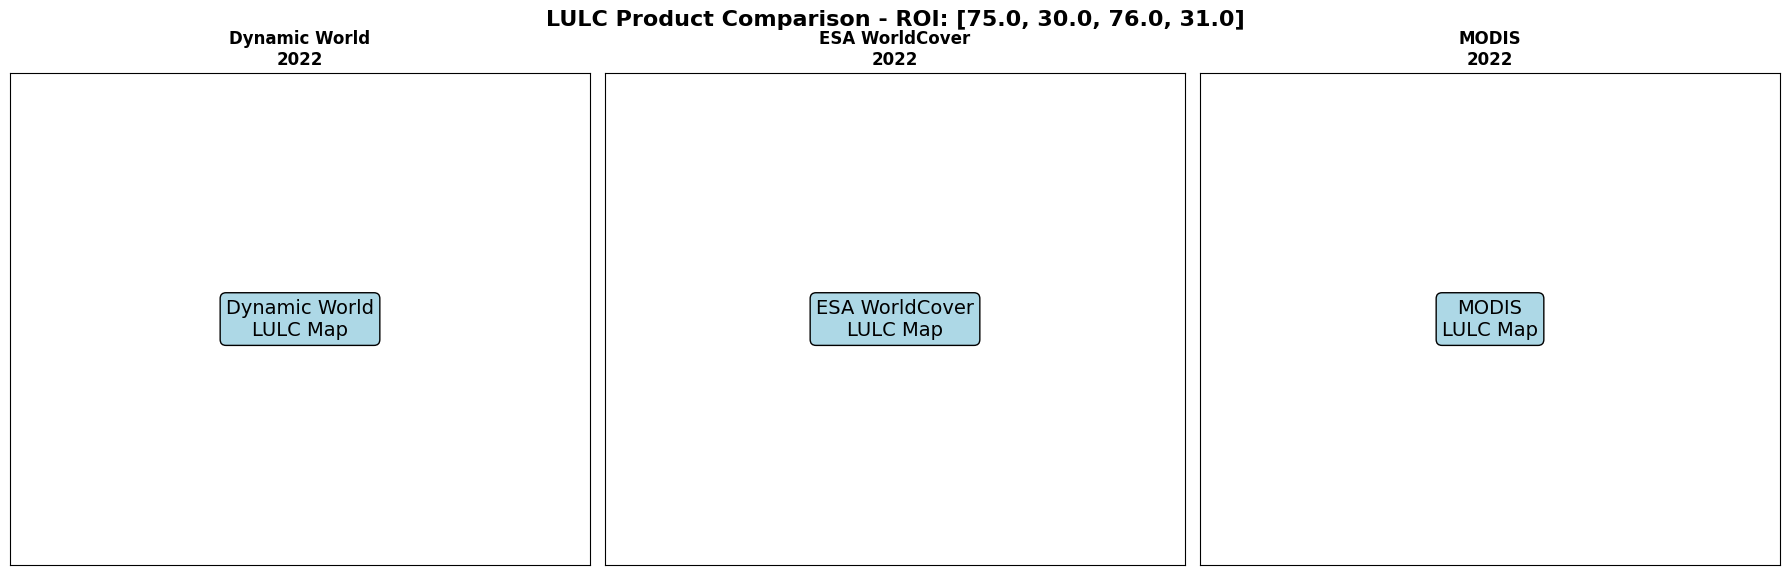

✓ LULC product comparison completed

4. Creating irrigation-specific LULC analysis...
✗ Irrigation LULC report failed: cannot access local variable 'dw_composition' where it is not associated with a value

LULC Analysis completed! Results saved to: lulc_irrigation_analysis
Loading Dynamic World LULC for period: 2022-06-01 to 2022-06-30
Creating interactive LULC map for dynamic_world
Overlay creation failed: "['value'] not in index"

LULC ANALYSIS COMPLETED SUCCESSFULLY!
Results available at: lulc_irrigation_analysis
Files generated:
• Interactive map: dynamic_world_interactive.html
• Static maps: *_static.png
• Composition analysis: *_composition.png
• Data files: *_composition.json
• Irrigation report: irrigation_lulc_report.txt
Loading Dynamic World LULC for period: 2022-06-01 to 2022-06-30
Creating interactive LULC map for dynamic_world
Overlay creation failed: "['value'] not in index"

LULC ANALYSIS COMPLETED SUCCESSFULLY!
Results available at: lulc_irrigation_analysis
Files genera

Exception: "['value'] not in index"

In [2]:
"""
Land Use Land Cover (LULC) Analysis using Google Earth Engine
Plots LULC from Sentinel-2 based products for irrigation analysis
"""

import ee
import geemap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import json
import folium
import rasterio
from rasterio.plot import show
import contextily as ctx
from datetime import datetime, timedelta
import warnings
import glob
from typing import Optional, Tuple
warnings.filterwarnings('ignore')

# Initialize Earth Engine
try:
    ee.Authenticate()
    ee.Initialize(project='ee-ishansinhagzb')
    print("Earth Engine initialized successfully!")
except Exception as e:
    print(f"Earth Engine initialization failed: {e}")
    print("Please run: earthengine authenticate")

class LULCAnalyzer:
    """
    Land Use Land Cover analyzer using Google Earth Engine
    """
    
    def __init__(self, roi_bounds=None):
        """
        Initialize LULC analyzer
        
        Args:
            roi_bounds: [min_lon, min_lat, max_lon, max_lat] or None for default
        """
        # Default ROI (Haryana region for irrigation analysis)
        self.roi_bounds = roi_bounds or [75.0, 30.0, 76.0, 31.0]
        self.roi = ee.Geometry.Rectangle(self.roi_bounds)
        
        # LULC product collections
        self.lulc_collections = {
            'dynamic_world': 'GOOGLE/DYNAMICWORLD/V1',
            'esa_worldcover': 'ESA/WorldCover/v100',
            'modis_lc': 'MODIS/006/MCD12Q1',
            'copernicus_lc': 'COPERNICUS/Landcover/100m/Proba-V-C3/Global'
        }
        
        # Dynamic World class names and colors
        self.dw_class_names = {
            0: 'Water',
            1: 'Trees',
            2: 'Grass',
            3: 'Flooded vegetation',
            4: 'Crops',
            5: 'Shrub & scrub',
            6: 'Built area',
            7: 'Bare ground',
            8: 'Snow & ice'
        }
        
        self.dw_colors = {
            0: '#419BDF',  # Water
            1: '#397D49',  # Trees  
            2: '#88B053',  # Grass
            3: '#7A87C6',  # Flooded vegetation
            4: '#E49635',  # Crops
            5: '#DFC35A',  # Shrub & scrub
            6: '#C4281B',  # Built area
            7: '#A59B8F',  # Bare ground
            8: '#B39FE1'   # Snow & ice
        }
        
        # ESA WorldCover class names and colors
        self.esa_class_names = {
            10: 'Tree cover',
            20: 'Shrubland',
            30: 'Grassland',
            40: 'Cropland',
            50: 'Built-up',
            60: 'Bare/sparse vegetation',
            70: 'Snow and ice',
            80: 'Permanent water bodies',
            90: 'Herbaceous wetland',
            95: 'Mangroves',
            100: 'Moss and lichen'
        }
        
        self.esa_colors = {
            10: '#006400',  # Tree cover
            20: '#FFBB22',  # Shrubland
            30: '#FFFF4C',  # Grassland
            40: '#F096FF',  # Cropland
            50: '#FA0000',  # Built-up
            60: '#B4B4B4',  # Bare/sparse vegetation
            70: '#F0F0F0',  # Snow and ice
            80: '#0064C8',  # Permanent water bodies
            90: '#0096A0',  # Herbaceous wetland
            95: '#00CF75',  # Mangroves
            100: '#FAE6A0'  # Moss and lichen
        }

    def get_dynamic_world_lulc(self, start_date, end_date):
        """
        Get Dynamic World LULC for specified time period
        
        Args:
            start_date: Start date string (YYYY-MM-DD)
            end_date: End date string (YYYY-MM-DD)
            
        Returns:
            ee.Image: LULC classification image
        """
        print(f"Loading Dynamic World LULC for period: {start_date} to {end_date}")
        
        # Load Dynamic World collection
        dw = ee.ImageCollection(self.lulc_collections['dynamic_world']) \
            .filterBounds(self.roi) \
            .filterDate(start_date, end_date)
        
        # Get the most common classification (mode) over the time period
        lulc_mode = dw.select('label').mode()
        
        # Clip to ROI
        lulc_clipped = lulc_mode.clip(self.roi)
        
        return lulc_clipped

    def get_esa_worldcover_lulc(self, year=2020):
        """
        Get ESA WorldCover LULC for specified year
        
        Args:
            year: Year for LULC (2020 available)
            
        Returns:
            ee.Image: LULC classification image
        """
        print(f"Loading ESA WorldCover LULC for year: {year}")
        
        # Load ESA WorldCover
        esa_lc = ee.ImageCollection(self.lulc_collections['esa_worldcover']) \
            .first() \
            .select('Map')
        
        # Clip to ROI
        lulc_clipped = esa_lc.clip(self.roi)
        
        return lulc_clipped

    def get_modis_lulc(self, year=2020):
        """
        Get MODIS Land Cover for specified year
        
        Args:
            year: Year for LULC
            
        Returns:
            ee.Image: LULC classification image
        """
        print(f"Loading MODIS Land Cover for year: {year}")
        
        # Load MODIS Land Cover
        modis_lc = ee.ImageCollection(self.lulc_collections['modis_lc']) \
            .filterDate(f'{year}-01-01', f'{year}-12-31') \
            .first() \
            .select('LC_Type1')
        
        # Clip to ROI
        lulc_clipped = modis_lc.clip(self.roi)
        
        return lulc_clipped

    def create_lulc_visualization_params(self, product='dynamic_world'):
        """
        Create visualization parameters for LULC products
        
        Args:
            product: LULC product name
            
        Returns:
            dict: Visualization parameters
        """
        if product == 'dynamic_world':
            return {
                'min': 0,
                'max': 8,
                'palette': [self.dw_colors[i] for i in range(9)]
            }
        elif product == 'esa_worldcover':
            return {
                'min': 10,
                'max': 100,
                'palette': [self.esa_colors[k] for k in sorted(self.esa_colors.keys())]
            }
        else:
            return {'min': 0, 'max': 10}

    def plot_interactive_lulc_map(self, lulc_image, product='dynamic_world', 
                                  title="Land Use Land Cover Map", save_path=None):
        """
        Create interactive LULC map using geemap
        
        Args:
            lulc_image: ee.Image LULC classification
            product: LULC product name
            title: Map title
            save_path: Path to save HTML map
            
        Returns:
            geemap.Map: Interactive map
        """
        print(f"Creating interactive LULC map for {product}")
        
        # Create map centered on ROI
        center_lat = (self.roi_bounds[1] + self.roi_bounds[3]) / 2
        center_lon = (self.roi_bounds[0] + self.roi_bounds[2]) / 2
        
        Map = geemap.Map(center=[center_lat, center_lon], zoom=10)
        
        # Add LULC layer
        vis_params = self.create_lulc_visualization_params(product)
        Map.addLayer(lulc_image, vis_params, f'{product.upper()} LULC')
        
        # Add ROI boundary
        roi_style = {'color': 'red', 'fillColor': '00000000'}
        Map.addLayer(self.roi, roi_style, 'ROI Boundary')
        
        # Add legend
        if product == 'dynamic_world':
            legend_dict = self.dw_class_names
            colors = [self.dw_colors[i] for i in sorted(self.dw_colors.keys())]
        elif product == 'esa_worldcover':
            legend_dict = self.esa_class_names
            colors = [self.esa_colors[k] for k in sorted(self.esa_colors.keys())]
        else:
            legend_dict = {}
            colors = []
        
        if legend_dict:
            Map.add_legend(legend_dict=legend_dict, title=f'{product.upper()} Classes')
        
        # Add layer control
        Map.add_layer_control()
        
        # Save map if path provided
        if save_path:
            Map.to_html(save_path)
            print(f"Interactive map saved to: {save_path}")
        
        return Map

    def download_lulc_data(self, lulc_image, filename, scale=30):
        """
        Download LULC data as GeoTIFF
        
        Args:
            lulc_image: ee.Image LULC classification
            filename: Output filename
            scale: Pixel scale in meters
        """
        print(f"Downloading LULC data to: {filename}")
        
        # Export image
        task = ee.batch.Export.image.toDrive(
            image=lulc_image,
            description=f'LULC_export_{filename}',
            folder='EarthEngine_Exports',
            fileNamePrefix=filename,
            region=self.roi,
            scale=scale,
            crs='EPSG:4326',
            maxPixels=1e9
        )
        
        task.start()
        print(f"Export task started. Check Google Drive for: {filename}")
        
        return task

    def create_static_lulc_plot(self, lulc_image, product='dynamic_world', 
                               title="Land Use Land Cover Map", save_path=None):
        """
        Create static LULC plot using matplotlib
        
        Args:
            lulc_image: ee.Image LULC classification
            product: LULC product name
            title: Plot title
            save_path: Path to save plot
        """
        print(f"Creating static LULC plot for {product}")
        
        try:
            # Get image as numpy array
            lulc_array = geemap.ee_to_numpy(lulc_image, region=self.roi, scale=30)
            
            # Create plot
            fig, ax = plt.subplots(figsize=(12, 10))
            
            # Plot LULC
            if product == 'dynamic_world':
                class_names = self.dw_class_names
                colors = [self.dw_colors[i] for i in range(9)]
                vmin, vmax = 0, 8
            elif product == 'esa_worldcover':
                class_names = self.esa_class_names
                colors = [self.esa_colors[k] for k in sorted(self.esa_colors.keys())]
                vmin, vmax = 10, 100
            else:
                class_names = {}
                colors = plt.cm.tab10.colors
                vmin, vmax = lulc_array.min(), lulc_array.max()
            
            # Create custom colormap
            from matplotlib.colors import ListedColormap
            if colors:
                cmap = ListedColormap(colors)
                im = ax.imshow(lulc_array, cmap=cmap, vmin=vmin, vmax=vmax)
            else:
                im = ax.imshow(lulc_array, cmap='tab10')
            
            # Add colorbar with class names
            if class_names:
                cbar = plt.colorbar(im, ax=ax, shrink=0.8)
                if product == 'dynamic_world':
                    tick_labels = [class_names[i] for i in range(9)]
                    cbar.set_ticks(range(9))
                    cbar.set_ticklabels(tick_labels)
                elif product == 'esa_worldcover':
                    tick_positions = list(sorted(class_names.keys()))
                    tick_labels = [class_names[k] for k in tick_positions]
                    cbar.set_ticks(tick_positions)
                    cbar.set_ticklabels(tick_labels)
            
            # Set title and labels
            ax.set_title(f'{title}\n{product.upper()}', fontsize=14, fontweight='bold')
            ax.set_xlabel('Longitude', fontsize=12)
            ax.set_ylabel('Latitude', fontsize=12)
            
            # Add grid
            ax.grid(True, alpha=0.3)
            
            # Add ROI info
            roi_text = f"ROI: [{self.roi_bounds[0]:.2f}, {self.roi_bounds[1]:.2f}] to [{self.roi_bounds[2]:.2f}, {self.roi_bounds[3]:.2f}]"
            ax.text(0.02, 0.98, roi_text, transform=ax.transAxes, 
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            plt.tight_layout()
            
            # Save plot
            if save_path:
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
                print(f"Static plot saved to: {save_path}")
            
            plt.show()
            
        except Exception as e:
            print(f"Error creating static plot: {e}")
            print("Using alternative method with geemap...")
            
            # Alternative: Use geemap to create static map
            Map = geemap.Map()
            vis_params = self.create_lulc_visualization_params(product)
            Map.addLayer(lulc_image, vis_params, f'{product.upper()} LULC')
            
            if save_path:
                # Convert to static image
                Map.to_image(save_path.replace('.png', '_geemap.png'))

    def analyze_lulc_composition(self, lulc_image, product='dynamic_world'):
        """
        Analyze LULC class composition in the ROI
        
        Args:
            lulc_image: ee.Image LULC classification
            product: LULC product name
            
        Returns:
            dict: LULC composition statistics
        """
        print(f"Analyzing LULC composition for {product}")
        
        # Calculate area for each class
        area_image = ee.Image.pixelArea()
        
        # Get class areas
        class_areas = lulc_image.addBands(area_image).reduceRegion(
            reducer=ee.Reducer.sum().group(groupField=0, groupName='class'),
            geometry=self.roi,
            scale=30,
            maxPixels=1e9
        )
        
        # Process results
        results = class_areas.getInfo()
        
        if product == 'dynamic_world':
            class_names = self.dw_class_names
        elif product == 'esa_worldcover':
            class_names = self.esa_class_names
        else:
            class_names = {}
        
        # Calculate composition
        composition = {}
        total_area = 0
        
        if 'groups' in results:
            for group in results['groups']:
                class_id = int(group['class'])
                area_sqm = group['sum']
                area_sqkm = area_sqm / 1e6
                
                class_name = class_names.get(class_id, f'Class_{class_id}')
                composition[class_name] = {
                    'class_id': class_id,
                    'area_sqkm': area_sqkm,
                    'area_sqm': area_sqm
                }
                total_area += area_sqkm
        
        # Calculate percentages
        for class_name in composition:
            composition[class_name]['percentage'] = (composition[class_name]['area_sqkm'] / total_area) * 100
        
        # Add total area
        composition['total'] = {
            'total_area_sqkm': total_area,
            'total_area_sqm': total_area * 1e6
        }
        
        return composition

    def create_composition_plots(self, composition, product='dynamic_world', save_path=None):
        """
        Create plots showing LULC composition
        
        Args:
            composition: LULC composition dictionary
            product: LULC product name
            save_path: Path to save plots
        """
        print(f"Creating LULC composition plots for {product}")
        
        # Extract data for plotting
        class_names = []
        areas = []
        percentages = []
        colors = []
        
        if product == 'dynamic_world':
            color_dict = self.dw_colors
        elif product == 'esa_worldcover':
            color_dict = self.esa_colors
        else:
            color_dict = {}
        
        for class_name, data in composition.items():
            if class_name != 'total':
                class_names.append(class_name)
                areas.append(data['area_sqkm'])
                percentages.append(data['percentage'])
                
                # Get color for this class
                class_id = data['class_id']
                color = color_dict.get(class_id, '#888888')
                colors.append(color)
        
        # Create subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
        
        # Pie chart
        wedges, texts, autotexts = ax1.pie(percentages, labels=class_names, colors=colors, 
                                          autopct='%1.1f%%', startangle=90)
        ax1.set_title(f'LULC Composition - {product.upper()}\nPie Chart', fontsize=14, fontweight='bold')
        
        # Bar chart
        bars = ax2.bar(class_names, areas, color=colors)
        ax2.set_title(f'LULC Composition - {product.upper()}\nArea Distribution', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Land Cover Class', fontsize=12)
        ax2.set_ylabel('Area (km²)', fontsize=12)
        ax2.tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, area in zip(bars, areas):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{area:.2f}', ha='center', va='bottom')
        
        # Add total area info
        total_area = composition['total']['total_area_sqkm']
        fig.suptitle(f'Land Use Land Cover Analysis\nTotal Area: {total_area:.2f} km²', 
                    fontsize=16, fontweight='bold', y=0.95)
        
        plt.tight_layout()
        
        # Save plot
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Composition plots saved to: {save_path}")
        
        plt.show()

    def compare_lulc_products(self, date_range=None, year=2020, save_dir=None):
        """
        Compare different LULC products for the same region
        
        Args:
            date_range: [start_date, end_date] for Dynamic World
            year: Year for other products
            save_dir: Directory to save comparison plots
        """
        print("Comparing different LULC products...")
        
        if date_range is None:
            date_range = [f'{year}-06-01', f'{year}-08-31']  # Summer season
        
        # Get LULC from different products
        lulc_products = {}
        
        try:
            # Dynamic World
            lulc_products['Dynamic World'] = self.get_dynamic_world_lulc(date_range[0], date_range[1])
            print("✓ Dynamic World loaded")
        except Exception as e:
            print(f"✗ Dynamic World failed: {e}")
        
        try:
            # ESA WorldCover
            lulc_products['ESA WorldCover'] = self.get_esa_worldcover_lulc(year)
            print("✓ ESA WorldCover loaded")
        except Exception as e:
            print(f"✗ ESA WorldCover failed: {e}")
        
        try:
            # MODIS Land Cover
            lulc_products['MODIS'] = self.get_modis_lulc(year)
            print("✓ MODIS Land Cover loaded")
        except Exception as e:
            print(f"✗ MODIS Land Cover failed: {e}")
        
        # Create comparison plots
        n_products = len(lulc_products)
        if n_products == 0:
            print("No LULC products successfully loaded!")
            return
        
        fig, axes = plt.subplots(1, n_products, figsize=(6*n_products, 6))
        if n_products == 1:
            axes = [axes]
        
        for i, (product_name, lulc_image) in enumerate(lulc_products.items()):
            try:
                # Get visualization parameters
                if 'Dynamic' in product_name:
                    vis_params = self.create_lulc_visualization_params('dynamic_world')
                elif 'ESA' in product_name:
                    vis_params = self.create_lulc_visualization_params('esa_worldcover')
                else:
                    vis_params = {'min': 0, 'max': 10}
                
                # Create individual plot for each product
                ax = axes[i]
                ax.set_title(f'{product_name}\n{year}', fontsize=12, fontweight='bold')
                
                # For now, show product name (actual plotting would need data download)
                ax.text(0.5, 0.5, f'{product_name}\nLULC Map', 
                       ha='center', va='center', transform=ax.transAxes,
                       fontsize=14, bbox=dict(boxstyle='round', facecolor='lightblue'))
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
                ax.set_xticks([])
                ax.set_yticks([])
                
            except Exception as e:
                print(f"Error plotting {product_name}: {e}")
                axes[i].text(0.5, 0.5, f'Error loading\n{product_name}', 
                           ha='center', va='center', transform=axes[i].transAxes)
        
        plt.suptitle(f'LULC Product Comparison - ROI: {self.roi_bounds}', 
                    fontsize=16, fontweight='bold', y=0.95)
        plt.tight_layout()
        
        if save_dir:
            save_path = Path(save_dir) / f'lulc_comparison_{year}.png'
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Comparison plot saved to: {save_path}")
        
        plt.show()
        
        return lulc_products

# ---------------- NEW: geemap overlay helpers (no matplotlib plots) ----------------

def _find_monthly_irrigation_csv(base_dir: str = "./two_phase_results_5yr") -> Optional[Path]:
    """
    Find the monthly_irrigation_all_grids.csv produced by the runner.
    """
    base_path = Path(base_dir)
    pattern = str(base_path / "**" / "monthly_irrigation_all_grids.csv")
    matches = glob.glob(pattern, recursive=True)
    if not matches:
        print(f"No monthly_irrigation_all_grids.csv found under {base_dir}")
        return None
    latest = max(matches, key=lambda x: Path(x).stat().st_mtime)
    return Path(latest)

def _month_range(year: int, month: int) -> Tuple[str, str]:
    """
    Return first and last date strings for a given year-month.
    """
    start = pd.Timestamp(year=year, month=month, day=1)
    end = start + pd.offsets.MonthEnd(1)
    return start.strftime("%Y-%m-%d"), end.strftime("%Y-%m-%d")

def _load_monthly_irrigation_for_month(monthly_csv: Path, year: int, month: int) -> pd.DataFrame:
    """
    Load monthly irrigation data for a given month-year from monthly_irrigation_all_grids.csv
    """
    df = pd.read_csv(monthly_csv)
    if 'year_month' in df.columns:
        df['year_month'] = pd.to_datetime(df['year_month'])
        mask = (df['year_month'].dt.year == year) & (df['year_month'].dt.month == month)
        month_df = df.loc[mask].copy()
    else:
        # Fallback if year/month columns exist separately
        month_df = df[(df['year'] == year) & (df['month'] == month)].copy()
    # Ensure required columns exist
    if not {'latitude', 'longitude'}.issubset(month_df.columns):
        raise ValueError("Monthly CSV must contain 'latitude' and 'longitude' columns")
    return month_df

def create_lulc_irrigation_geemap_overlay(
    roi_bounds: Optional[list] = None,
    product: str = 'dynamic_world',
    year: int = 2022,
    month: int = 6,
    results_dir: str = "./two_phase_results_5yr",
    heatmap_metric: str = "volume",   # 'volume' or 'events'
    heatmap_radius: int = 25,
    heatmap_blur: int = 15,
    save_html: Optional[Path] = None
):
    """
    Create a geemap overlay: LULC as base + irrigation heatmap overlay for a chosen month.

    Args:
        roi_bounds: [min_lon, min_lat, max_lon, max_lat]
        product: 'dynamic_world' or 'esa_worldcover'
        year, month: month to visualize irrigation overlay
        results_dir: base directory containing monthly_irrigation_all_grids.csv
        heatmap_metric: 'volume' => irrigation_volume_mm, 'events' => irrigation_events
        heatmap_radius: heatmap point radius in pixels
        heatmap_blur: heatmap blur parameter
        save_html: optional Path to save as HTML

    Returns:
        geemap.Map with layers added.
    """
    roi_bounds = roi_bounds or [75.0, 30.0, 76.0, 31.0]
    analyzer = LULCAnalyzer(roi_bounds)

    # Build LULC image for this month
    start_date, end_date = _month_range(year, month)
    if product == 'dynamic_world':
        lulc_image = analyzer.get_dynamic_world_lulc(start_date, end_date)
    elif product == 'esa_worldcover':
        lulc_image = analyzer.get_esa_worldcover_lulc(year if year else 2020)
    else:
        lulc_image = analyzer.get_dynamic_world_lulc(start_date, end_date)

    # Create geemap Map and add LULC layer + ROI boundary
    m = analyzer.plot_interactive_lulc_map(
        lulc_image, product=product,
        title=f"LULC + Irrigation Overlay {year}-{month:02d}"
    )

    # Load monthly irrigation CSV for selected month/year
    monthly_csv = _find_monthly_irrigation_csv(results_dir)
    if monthly_csv is None:
        print("Irrigation monthly CSV not found; returning LULC-only map.")
        if save_html:
            m.to_html(save_html)
        return m

    month_df = _load_monthly_irrigation_for_month(monthly_csv, year, month)
    if month_df.empty:
        print(f"No irrigation data for {year}-{month:02d} in {monthly_csv}")
        if save_html:
            m.to_html(save_html)
        return m

    # Determine metric column
    if heatmap_metric.lower().startswith('vol'):
        value_col = 'irrigation_volume_mm'
        layer_name = f'Irrigation Volume Heatmap ({year}-{month:02d})'
    else:
        value_col = 'irrigation_events'
        layer_name = f'Irrigation Events Heatmap ({year}-{month:02d})'

    # Normalize NaNs
    if value_col not in month_df.columns:
        raise ValueError(f"Column '{value_col}' not found in monthly CSV")
    month_df[value_col] = month_df[value_col].fillna(0.0)

    # Add heatmap overlay (client-side) using geemap
    # Note: geemap Map.add_heatmap expects a DataFrame
    m.add_heatmap(
        data=month_df,
        latitude='latitude',
        longitude='longitude',
        weight=value_col,
        name=layer_name,
        radius=heatmap_radius,
        blur=heatmap_blur,
        max_zoom=18
    )

    # Optional: add points layer as reference
    m.add_points_from_xy(
        month_df,
        x='longitude',
        y='latitude',
        popup=[value_col, 'grid_id'] if 'grid_id' in month_df.columns else [value_col],
        layer_name=f'Points ({value_col})',
        color='white',
        fill_color='black'
    )

    # Layer control already added in plot_interactive_lulc_map
    if save_html:
        m.to_html(save_html)
        print(f"Overlay map saved to: {save_html}")

    return m

# ---------------- END new helpers ----------------

def create_irrigation_lulc_analysis(roi_bounds=None, time_period=None, output_dir='lulc_results'):
    """
    Main function to create LULC analysis for irrigation detection
    
    Args:
        roi_bounds: [min_lon, min_lat, max_lon, max_lat]
        time_period: [start_date, end_date] or year
        output_dir: Output directory for results
    """
    print("Starting LULC Analysis for Irrigation Detection")
    print("=" * 50)
    
    # Default parameters for irrigation analysis
    if roi_bounds is None:
        roi_bounds = [75.0, 30.0, 76.0, 31.0]  # Haryana region
    
    if time_period is None:
        time_period = ['2022-06-01', '2022-08-31']  # Summer growing season
    
    # Create output directory
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Initialize LULC analyzer
    analyzer = LULCAnalyzer(roi_bounds)
    
    print(f"ROI: {roi_bounds}")
    print(f"Time period: {time_period}")
    print(f"Output directory: {output_dir}")
    print("-" * 50)
    
    # 1. Get Dynamic World LULC (best for agricultural areas)
    print("1. Loading Dynamic World LULC...")
    try:
        if isinstance(time_period, list) and len(time_period) == 2:
            dw_lulc = analyzer.get_dynamic_world_lulc(time_period[0], time_period[1])
        else:
            year = time_period if isinstance(time_period, int) else 2022
            dw_lulc = analyzer.get_dynamic_world_lulc(f'{year}-06-01', f'{year}-08-31')
        
        # Create interactive map
        print("Creating interactive Dynamic World map...")
        interactive_map = analyzer.plot_interactive_lulc_map(
            dw_lulc, 'dynamic_world', 
            "Dynamic World LULC - Irrigation Analysis Region",
            save_path=output_path / 'dynamic_world_interactive.html'
        )
        
        # Create static plot
        print("Creating static Dynamic World plot...")
        analyzer.create_static_lulc_plot(
            dw_lulc, 'dynamic_world',
            f"Dynamic World LULC - {time_period}",
            save_path=output_path / 'dynamic_world_static.png'
        )
        
        # Analyze composition
        print("Analyzing Dynamic World composition...")
        dw_composition = analyzer.analyze_lulc_composition(dw_lulc, 'dynamic_world')
        
        # Create composition plots
        analyzer.create_composition_plots(
            dw_composition, 'dynamic_world',
            save_path=output_path / 'dynamic_world_composition.png'
        )
        
        # Save composition data
        with open(output_path / 'dynamic_world_composition.json', 'w') as f:
            json.dump(dw_composition, f, indent=2, default=str)
        
        print("✓ Dynamic World analysis completed")
        
    except Exception as e:
        print(f"✗ Dynamic World analysis failed: {e}")
    
    # 2. Get ESA WorldCover LULC
    print("\n2. Loading ESA WorldCover LULC...")
    try:
        year = 2020  # ESA WorldCover available for 2020
        esa_lulc = analyzer.get_esa_worldcover_lulc(year)
        
        # Create static plot
        print("Creating ESA WorldCover plot...")
        analyzer.create_static_lulc_plot(
            esa_lulc, 'esa_worldcover',
            f"ESA WorldCover LULC - {year}",
            save_path=output_path / 'esa_worldcover_static.png'
        )
        
        # Analyze composition
        print("Analyzing ESA WorldCover composition...")
        esa_composition = analyzer.analyze_lulc_composition(esa_lulc, 'esa_worldcover')
        
        # Create composition plots
        analyzer.create_composition_plots(
            esa_composition, 'esa_worldcover',
            save_path=output_path / 'esa_worldcover_composition.png'
        )
        
        # Save composition data
        with open(output_path / 'esa_worldcover_composition.json', 'w') as f:
            json.dump(esa_composition, f, indent=2, default=str)
        
        print("✓ ESA WorldCover analysis completed")
        
    except Exception as e:
        print(f"✗ ESA WorldCover analysis failed: {e}")
    
    # 3. Compare LULC products
    print("\n3. Creating LULC product comparison...")
    try:
        comparison_year = 2022 if isinstance(time_period, list) else time_period
        lulc_products = analyzer.compare_lulc_products(
            date_range=time_period if isinstance(time_period, list) else None,
            year=comparison_year,
            save_dir=output_path
        )
        print("✓ LULC product comparison completed")
        
    except Exception as e:
        print(f"✗ LULC product comparison failed: {e}")
    
    # 4. Create irrigation-specific analysis
    print("\n4. Creating irrigation-specific LULC analysis...")
    try:
        create_irrigation_lulc_report(dw_composition, esa_composition, output_path)
        print("✓ Irrigation LULC report created")
        
    except Exception as e:
        print(f"✗ Irrigation LULC report failed: {e}")
    
    print(f"\nLULC Analysis completed! Results saved to: {output_path}")
    
    # NEW: also generate a geemap overlay (LULC + irrigation heatmap) for one month
    try:
        # Default demo: June 2022 overlay
        overlay_html = output_path / 'lulc_irrigation_overlay_2022_06.html'
        create_lulc_irrigation_geemap_overlay(
            roi_bounds=roi_bounds,
            product='dynamic_world',
            year=2022,
            month=6,
            results_dir="./two_phase_results_5yr",
            heatmap_metric="volume",
            heatmap_radius=25,
            heatmap_blur=15,
            save_html=overlay_html
        )
        print(f"✓ Geemap overlay created: {overlay_html}")
    except Exception as e:
        print(f"Overlay creation failed: {e}")

    return analyzer, output_path

def create_irrigation_lulc_report(dw_composition, esa_composition, output_path):
    """
    Create irrigation-specific LULC analysis report
    
    Args:
        dw_composition: Dynamic World composition data
        esa_composition: ESA WorldCover composition data
        output_path: Output directory path
    """
    # Calculate irrigation-relevant metrics
    report_lines = [
        "IRRIGATION-SPECIFIC LULC ANALYSIS REPORT",
        "=" * 50,
        f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
        "",
        "AGRICULTURAL LAND ANALYSIS:",
        "-" * 30
    ]
    
    # Dynamic World agricultural analysis
    if 'Crops' in dw_composition:
        crop_area = dw_composition['Crops']['area_sqkm']
        crop_pct = dw_composition['Crops']['percentage']
        report_lines.extend([
            f"Dynamic World - Crop Area: {crop_area:.2f} km² ({crop_pct:.1f}%)"
        ])
    
    if 'Grass' in dw_composition:
        grass_area = dw_composition['Grass']['area_sqkm']
        grass_pct = dw_composition['Grass']['percentage']
        report_lines.extend([
            f"Dynamic World - Grass Area: {grass_area:.2f} km² ({grass_pct:.1f}%)"
        ])
    
    # ESA WorldCover agricultural analysis
    if 'Cropland' in esa_composition:
        cropland_area = esa_composition['Cropland']['area_sqkm']
        cropland_pct = esa_composition['Cropland']['percentage']
        report_lines.extend([
            f"ESA WorldCover - Cropland Area: {cropland_area:.2f} km² ({cropland_pct:.1f}%)"
        ])
    
    # Water bodies (important for irrigation)
    report_lines.extend([
        "",
        "WATER RESOURCES ANALYSIS:",
        "-" * 30
    ])
    
    if 'Water' in dw_composition:
        water_area = dw_composition['Water']['area_sqkm']
        water_pct = dw_composition['Water']['percentage']
        report_lines.extend([
            f"Dynamic World - Water Bodies: {water_area:.2f} km² ({water_pct:.1f}%)"
        ])
    
    if 'Permanent water bodies' in esa_composition:
        water_esa_area = esa_composition['Permanent water bodies']['area_sqkm']
        water_esa_pct = esa_composition['Permanent water bodies']['percentage']
        report_lines.extend([
            f"ESA WorldCover - Water Bodies: {water_esa_area:.2f} km² ({water_esa_pct:.1f}%)"
        ])
    
    # Built-up areas (urbanization pressure)
    report_lines.extend([
        "",
        "URBANIZATION ANALYSIS:",
        "-" * 25
    ])
    
    if 'Built area' in dw_composition:
        built_area = dw_composition['Built area']['area_sqkm']
        built_pct = dw_composition['Built area']['percentage']
        report_lines.extend([
            f"Dynamic World - Built Areas: {built_area:.2f} km² ({built_pct:.1f}%)"
        ])
    
    if 'Built-up' in esa_composition:
        built_esa_area = esa_composition['Built-up']['area_sqkm']
        built_esa_pct = esa_composition['Built-up']['percentage']
        report_lines.extend([
            f"ESA WorldCover - Built-up Areas: {built_esa_area:.2f} km² ({built_esa_pct:.1f}%)"
        ])
    
    # Irrigation potential assessment
    report_lines.extend([
        "",
        "IRRIGATION POTENTIAL ASSESSMENT:",
        "-" * 35
    ])
    
    # Calculate total agricultural area from Dynamic World
    agri_classes = ['Crops', 'Grass']
    total_agri_dw = sum([dw_composition.get(cls, {}).get('area_sqkm', 0) for cls in agri_classes])
    total_area_dw = dw_composition['total']['total_area_sqkm']
    agri_pct_dw = (total_agri_dw / total_area_dw) * 100
    
    report_lines.extend([
        f"Total Agricultural Area (DW): {total_agri_dw:.2f} km² ({agri_pct_dw:.1f}%)",
        f"Irrigation Potential: {'High' if agri_pct_dw > 50 else 'Medium' if agri_pct_dw > 25 else 'Low'}",
        "",
        "RECOMMENDATIONS:",
        "-" * 15,
        "• Focus irrigation monitoring on crop-dominated areas",
        "• Consider water body proximity for irrigation source analysis",
        "• Monitor built-up expansion impact on agricultural land",
        "• Use Dynamic World for detailed crop monitoring"
    ])
    
    # Save report
    report_file = output_path / 'irrigation_lulc_report.txt'
    with open(report_file, 'w') as f:
        f.write('\n'.join(report_lines))
    
    print(f"Irrigation LULC report saved to: {report_file}")

# Example usage and main execution
if __name__ == "__main__":
    # Example usage for irrigation analysis in Haryana, India
    roi_haryana = [75.0, 30.0, 76.0, 31.0]  # Haryana agricultural region
    time_period = ['2022-06-01', '2022-08-31']  # Kharif season
    
    print("LULC Analysis for Irrigation Detection")
    print("=" * 40)
    print("Region: Haryana, India")
    print("Purpose: Agricultural land cover analysis for irrigation monitoring")
    print("Time: Summer growing season 2022")
    print("=" * 40)
    
    try:
        # Run complete LULC analysis
        analyzer, results_path = create_irrigation_lulc_analysis(
            roi_bounds=roi_haryana,
            time_period=time_period,
            output_dir='lulc_irrigation_analysis'
        )
        
        print("\n" + "=" * 40)
        print("LULC ANALYSIS COMPLETED SUCCESSFULLY!")
        print(f"Results available at: {results_path}")
        print("Files generated:")
        print("• Interactive map: dynamic_world_interactive.html")
        print("• Static maps: *_static.png")
        print("• Composition analysis: *_composition.png")
        print("• Data files: *_composition.json")
        print("• Irrigation report: irrigation_lulc_report.txt")
        print("=" * 40)
        
    except Exception as e:
        print(f"Error in LULC analysis: {e}")
        print("Please ensure:")
        print("1. Earth Engine is authenticated: earthengine authenticate")
        print("2. Required packages are installed: geemap, folium, contextily")
        print("3. Internet connection is available")

# Build and display LULC + irrigation geemap overlay for a target month
from pathlib import Path

# Parameters
roi_bounds = [75.0, 30.0, 76.0, 31.0]  # [min_lon, min_lat, max_lon, max_lat]
year, month = 2022, 6
results_dir = "./two_phase_results_5yr"

# Create overlay map and display inline
overlay_html = Path('lulc_irrigation_analysis') / f'lulc_irrigation_overlay_{year}_{month:02d}.html'
m = create_lulc_irrigation_geemap_overlay(
    roi_bounds=roi_bounds,
    product='dynamic_world',
    year=year,
    month=month,
    results_dir=results_dir,
    heatmap_metric='volume',  # or 'events'
    heatmap_radius=25,
    heatmap_blur=15,
    save_html=overlay_html
)
m